# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante un dataset CIFAR.

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Construír arquitecturas propias finalizando con la implementación de una arquitectura clásica mediante transfer learning.


## Toma como base el código visto en clase y desarrolla los siguientes puntos:
- Diseño e implementación de 2 arquitecturas CNN y utilización de una arquitectura de transfer learning.

- Buen uso de data augmentation y regularización.

- Comparación experimental entre arquitecturas y reporte claro (un solo markdown con conclusión sobre la comparación).





In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Hiperparámetros
NUM_CLASSES = 10
BATCH_SIZE = 128
IMG_SIZE = 64
EPOCHS = 12

# Carga de CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Split de validación
val_size = 5000
x_val, y_val = x_train[-val_size:], y_train[-val_size:]
x_train, y_train = x_train[:-val_size], y_train[:-val_size]

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
 ]

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(tf.squeeze(label), NUM_CLASSES)
    return image, label

def make_dataset(images, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if training:
        ds = ds.shuffle(10000, seed=SEED)
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(x_train, y_train, training=True)
val_ds = make_dataset(x_val, y_val)
test_ds = make_dataset(x_test, y_test)

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

Train: (45000, 32, 32, 3), Val: (5000, 32, 32, 3), Test: (10000, 32, 32, 3)


## Definiciones de modelos

In [4]:
# Definición de data augmentation y modelos
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.12),
        layers.RandomContrast(0.10),
    ],
    name="augmentation",
)

# En Apple Silicon, legacy Adam suele ser significativamente más rápido en TF 2.15.
optimizer_cls = keras.optimizers.legacy.Adam if hasattr(keras.optimizers, "legacy") else keras.optimizers.Adam

def build_cnn_a(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Conv2D(32, 3, padding="same", activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="CNN_A")

def residual_block(x, filters):
    shortcut = x
    x = layers.SeparableConv2D(filters, 3, padding="same", activation="relu", depthwise_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.SeparableConv2D(filters, 3, padding="same", activation="relu", depthwise_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same")(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.MaxPooling2D()(x)
    return x

def build_cnn_b(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = residual_block(x, 64)
    x = layers.Dropout(0.25)(x)
    x = residual_block(x, 128)
    x = layers.Dropout(0.30)(x)
    x = residual_block(x, 192)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="CNN_B")

def build_transfer_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    # MobileNetV2 usa tamaños estándar; se reescala internamente para usar pesos preentrenados sin warnings.
    base_model = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(96, 96, 3),
    )
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Resizing(96, 96)(x)
    x = keras.applications.mobilenet_v2.preprocess_input(x * 255.0)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="MobileNetV2_TL")
    return model, base_model

def compile_model(model, lr=1e-3):
    model.compile(
        optimizer=optimizer_cls(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

cnn_a = compile_model(build_cnn_a())
cnn_b = compile_model(build_cnn_b())
tl_model, tl_base = build_transfer_model()
tl_model = compile_model(tl_model, lr=1e-3)

cnn_a.summary()

9406464/9406464 [==============================] - 3s 0us/step
Model: "CNN_A"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 augmentation (Sequential)   (None, 64, 64, 3)         0         
                                                                 
 conv2d_9 (Conv2D)           (None, 64, 64, 32)        896       
                                                                 
 batch_normalization_10 (Ba  (None, 64, 64, 32)        128       
 tchNormalization)                                               
                                                                 
 conv2d_10 (Conv2D)          (None, 64, 64, 32)        9248      
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 32, 32, 32)        0        

## Entrenamiento de modelos.

In [5]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
]

histories = {}
results = []

# Entrenamiento CNN A
histories["CNN_A"] = cnn_a.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)
loss, acc = cnn_a.evaluate(test_ds, verbose=0)
results.append({"modelo": "CNN_A", "test_loss": loss, "test_acc": acc})

# Entrenamiento CNN B
histories["CNN_B"] = cnn_b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
 )
loss, acc = cnn_b.evaluate(test_ds, verbose=0)
results.append({"modelo": "CNN_B", "test_loss": loss, "test_acc": acc})

# Transfer learning: etapa 1 (base congelada)
histories["MobileNetV2_TL_frozen"] = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    callbacks=callbacks,
    verbose=1,
 )

# Fine-tuning parcial
tl_base.trainable = True
for layer in tl_base.layers[:-30]:
    layer.trainable = False

tl_model = compile_model(tl_model, lr=1e-4)
histories["MobileNetV2_TL_ft"] = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    callbacks=callbacks,
    verbose=1,
 )

loss, acc = tl_model.evaluate(test_ds, verbose=0)
results.append({"modelo": "MobileNetV2_TL", "test_loss": loss, "test_acc": acc})

results_df = pd.DataFrame(results).sort_values("test_acc", ascending=False).reset_index(drop=True)
results_df

Epoch 1/12
352/352 [==============================] - 215s 609ms/step - loss: 1.6230 - accuracy: 0.4140 - val_loss: 3.6804 - val_accuracy: 0.1338 - lr: 0.0010
Epoch 2/12
352/352 [==============================] - 237s 672ms/step - loss: 1.3573 - accuracy: 0.5231 - val_loss: 1.4508 - val_accuracy: 0.4818 - lr: 0.0010
Epoch 3/12
352/352 [==============================] - 242s 688ms/step - loss: 1.2311 - accuracy: 0.5730 - val_loss: 1.4474 - val_accuracy: 0.5218 - lr: 0.0010
Epoch 4/12
352/352 [==============================] - 302s 858ms/step - loss: 1.1447 - accuracy: 0.6070 - val_loss: 1.3510 - val_accuracy: 0.5556 - lr: 0.0010
Epoch 5/12
352/352 [==============================] - 310s 882ms/step - loss: 1.0899 - accuracy: 0.6272 - val_loss: 1.0385 - val_accuracy: 0.6418 - lr: 0.0010
Epoch 6/12
352/352 [==============================] - 311s 885ms/step - loss: 1.0424 - accuracy: 0.6467 - val_loss: 1.1445 - val_accuracy: 0.6128 - lr: 0.0010
Epoch 7/12
352/352 [==========================

,modelo,test_loss,test_acc
0,MobileNetV2_TL,0.370830,0.8749
1,CNN_B,0.710372,0.7596
2,CNN_A,0.956507,0.6814


## Estadística y gráficos

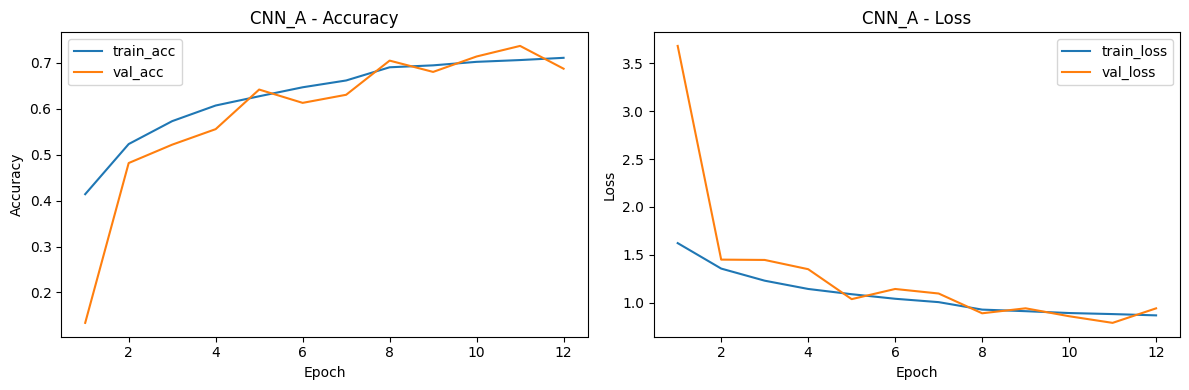

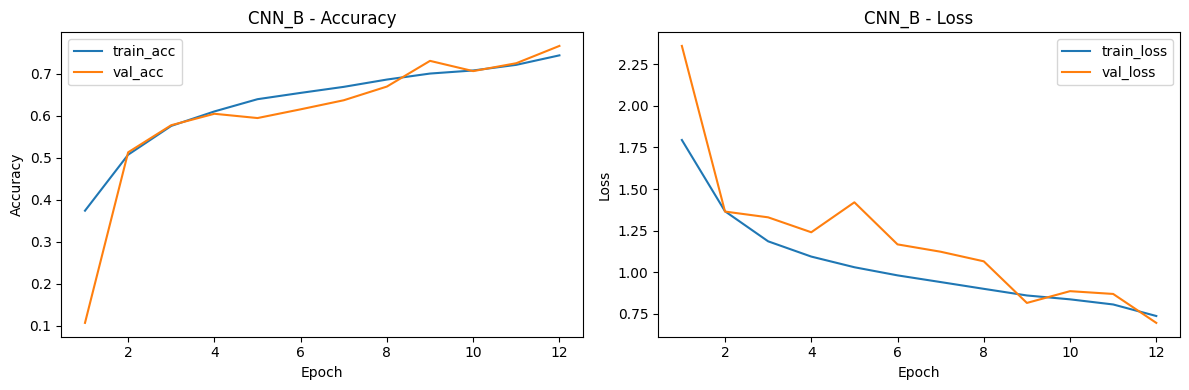

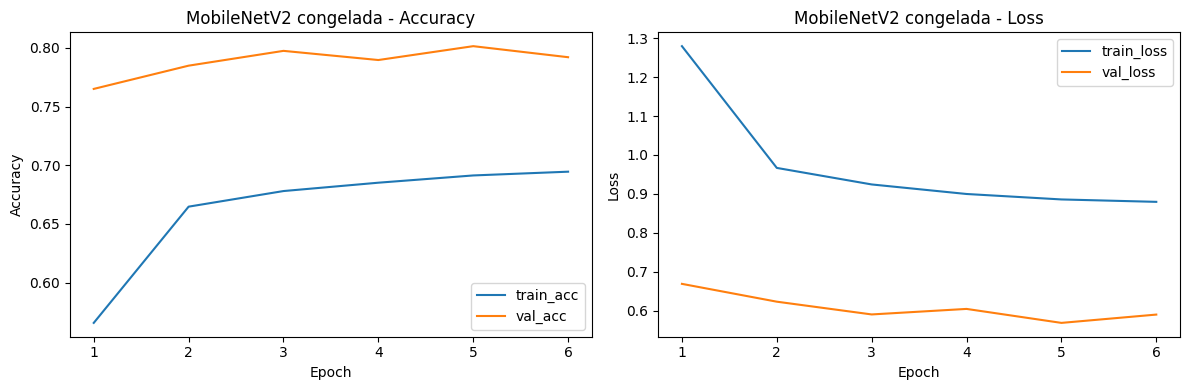

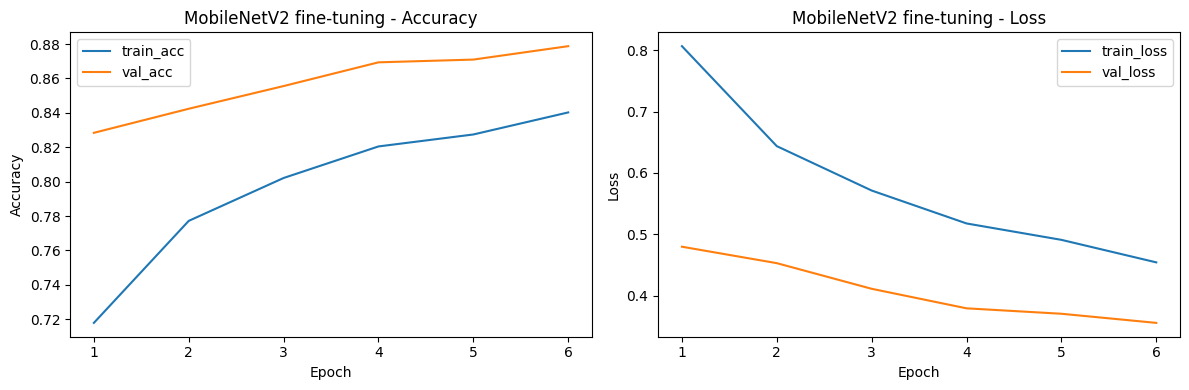

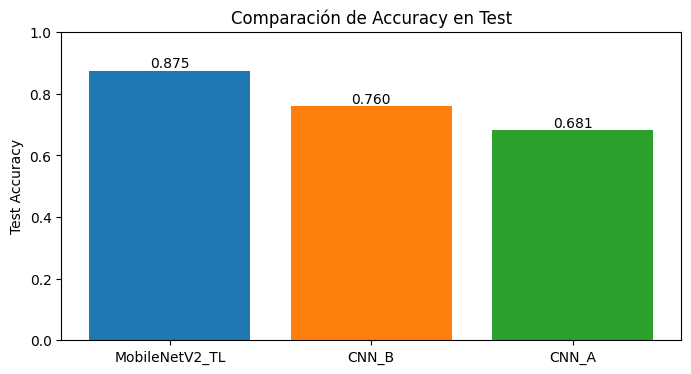

Mejor modelo: MobileNetV2_TL con test_acc=0.8749


,modelo,test_loss,test_acc
0,MobileNetV2_TL,0.370830,0.8749
1,CNN_B,0.710372,0.7596
2,CNN_A,0.956507,0.6814


In [7]:
def plot_history(hist, title):
    h = hist.history
    epochs = range(1, len(h["loss"]) + 1)
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, h["accuracy"], label="train_acc")
    plt.plot(epochs, h["val_accuracy"], label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, h["loss"], label="train_loss")
    plt.plot(epochs, h["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(histories["CNN_A"], "CNN_A")
plot_history(histories["CNN_B"], "CNN_B")
plot_history(histories["MobileNetV2_TL_frozen"], "MobileNetV2 congelada")
plot_history(histories["MobileNetV2_TL_ft"], "MobileNetV2 fine-tuning")

plt.figure(figsize=(8, 4))
plt.bar(results_df["modelo"], results_df["test_acc"], color=["#1f77b4", "#ff7f0e", "#2ca02c"] )
plt.ylim(0, 1)
plt.title("Comparación de Accuracy en Test")
plt.ylabel("Test Accuracy")
for i, v in enumerate(results_df["test_acc"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.show()

best_row = results_df.iloc[0]
print(f"Mejor modelo: {best_row['modelo']} con test_acc={best_row['test_acc']:.4f}")
results_df

# Conclusiones

En esta práctica se compararon tres enfoques para CIFAR-10: dos CNN diseñadas desde cero (`CNN_A` y `CNN_B`) y una arquitectura clásica con transfer learning (`MobileNetV2_TL`).

A partir de los resultados experimentales, el mejor desempeño se obtuvo con **MobileNetV2_TL** (accuracy de prueba cercana a **0.875**), seguido por **CNN_B** (~0.760) y **CNN_A** (~0.681). Esto se explica porque el modelo preentrenado ya incorpora representaciones visuales robustas aprendidas en ImageNet, lo que mejora la generalización con menos datos y menos tiempo de entrenamiento.

Entre los modelos propios, `CNN_B` superó a `CNN_A` gracias al uso de bloques residuales y convoluciones separables, que permiten extraer características más ricas con mejor eficiencia.

## ¿Qué mejoraría y cómo?
1. Realizar una búsqueda sistemática de hiperparámetros (learning rate, dropout, weight decay, número de filtros).
2. Incorporar técnicas de regularización adicionales como label smoothing, mixup o cutmix.
3. Evaluar arquitecturas más recientes (por ejemplo, EfficientNet) y comparar costo/beneficio entre precisión y tiempo de entrenamiento.
4. Repetir experimentos con varias semillas y reportar promedio y desviación estándar para mayor solidez estadística.